# Spherical-harmonics configuration gallery

Companion to `spots_configurations.ipynb`: instead of `add_spots`, every panel is a *superposition* of `Y_l^m` modes evaluated at the icosphere face centres. The four configurations span four ways to build a complex surface field from a small set of harmonics — multi-`ℓ` cross-mode, same-`ℓ` multiplet, tilted-axis twin, and a pure zonal stack. Same camera, colormap and rasterisation as the spots gallery so the two figures live side-by-side in the paper.

In [1]:
import sys
sys.path.append('../../../src')

from spice.models import IcosphereModel
from spice.models.utils import spherical_harmonic_with_tilt

import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import art3d

%matplotlib inline

## Base mesh

Same icosphere as the spots gallery. The mesh's `parameters` field is irrelevant here — `Y_l^m` is evaluated directly on `d_centers` and used as a per-face scalar to colour each triangle.

In [2]:
T_BASE = 5800.0   # K, kept only so the mesh has a parameter slot

base_mesh = IcosphereModel.construct(
    n_vertices=2000,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([T_BASE]),
    parameter_names=['teff'],
    override_log_g=False,
)

[spice] IcosphereModel constructed in 3.8 s


## Random multi-mode configurations

Each panel is a stack of random `Y_l^m` modes with a *different* count per panel — `N_MODES_PER_PANEL = [4, 8, 16, 24]` — so the gallery spans from a sparse few-mode field to a dense superposition. Within each panel: degree `ℓ ~ U[1, 8]`, order `m ~ U[0, ℓ]`, amplitude `w ~ N(0, 1)`, tilt axis `~ N(0, I_3)` (then unit-normalised), tilt angle `~ U[0, 360°]`. Each panel uses its own RNG seed so the four superpositions are independent and reproducible. The per-face scalar is the weighted sum of `Y_l^m` evaluated at the face centres, peak-normalised, then passed through a sign-preserving `√` stretch so mid-amplitude lobes remain visible.

The exact mode list for every panel is printed and exported in the next section.

In [10]:
Z_AXIS = jnp.array([0.0, 0.0, 1.0])

def mode(l, m, weight=1.0, tilt_axis=Z_AXIS, tilt_angle=0.0):
    return {'l': l, 'm': m, 'weight': weight, 'tilt_axis': tilt_axis, 'tilt_angle': tilt_angle}

N_MODES_PER_PANEL = [4, 8, 16, 24]
SEEDS = [11, 98, 42, 97]   # one per panel

def random_modes(seed, n_modes):
    rng = np.random.default_rng(seed)
    modes = []
    for _ in range(n_modes):
        l = int(rng.integers(1, 9))                  # ℓ in [1, 8]
        m = int(rng.integers(0, l + 1))              # m in [0, ℓ]
        weight = float(rng.normal(0.0, 1.0))         # w ~ N(0, 1)
        axis = rng.normal(size=3)
        axis = axis / (np.linalg.norm(axis) + 1e-12) # unit tilt axis
        angle = float(rng.uniform(0.0, 360.0))       # tilt angle in degrees
        modes.append(mode(l, m, weight=weight,
                          tilt_axis=jnp.asarray(axis), tilt_angle=angle))
    return modes

panel_letters = ['a', 'b', 'c', 'd']
configurations = [
    {'title': rf'{panel_letters[i]}) {N_MODES_PER_PANEL[i]} modes',
     'seed': SEEDS[i],
     'n_modes': N_MODES_PER_PANEL[i]}
    for i in range(len(SEEDS))
]
for cfg in configurations:
    cfg['modes'] = random_modes(cfg['seed'], cfg['n_modes'])

def harmonic_pattern(mesh, modes):
    Y_total = np.zeros(np.asarray(mesh.d_centers).shape[0])
    for mo in modes:
        Y = spherical_harmonic_with_tilt(int(mo['m']), int(mo['l']),
                                         mesh.d_centers, mo['tilt_axis'], float(mo['tilt_angle']))
        Y = np.asarray(Y)
        peak = np.max(np.abs(Y))
        if peak > 0:
            Y = Y / peak
        Y_total = Y_total + mo['weight'] * Y
    final_peak = np.max(np.abs(Y_total))
    return Y_total / final_peak if final_peak > 0 else Y_total

# Sign-preserving sqrt stretch so mid-amplitude lobes stay visible at high l.
def stretch(Y):
    return np.sign(Y) * np.sqrt(np.abs(Y))

patterns = [stretch(harmonic_pattern(base_mesh, c['modes'])) for c in configurations]

## Render the gallery

All panels share a single diverging `Normalize(-1, 1)` so positive and negative lobes of the synthesised field are immediately distinguishable. Camera, colormap, edge colour, rasterisation and colorbar layout match `spots_configurations.ipynb` exactly so the two figures can sit side-by-side in the paper.

In [11]:
import cmasher as cm

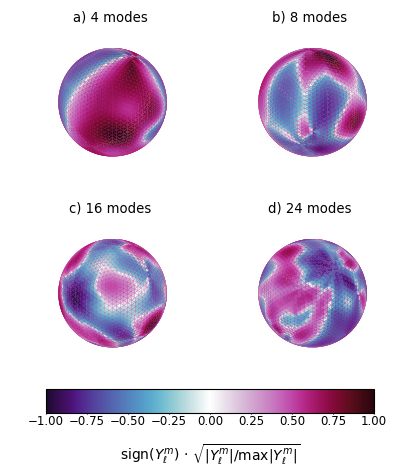

In [12]:
ROW_SPACING = 0.0
HEIGHT_PER_ROW = 2
CBAR_HEIGHT_RATIO = 0.1

CMAP = 'cmr.viola'
VIEW = dict(elev=15, azim=0)

norm = mpl.colors.Normalize(vmin=-1.0, vmax=1.0)
cmap = mpl.colormaps[CMAP]

def strip_axes(ax):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('none')
    ax.grid(False)
    ax.set_axis_off()
    ax.set_facecolor('none')

def draw_mesh(ax, mesh, scalar):
    poly = art3d.Poly3DCollection(
        np.asarray(mesh.mesh_elements),
        facecolors=cmap(norm(scalar)),
        edgecolor='mediumvioletred', linewidths=0.05)
    poly.set_rasterized(True)
    ax.add_collection(poly)
    lim = 1.05 * float(mesh.radius)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(**VIEW)

n_cols = 2
n_rows = -(-len(configurations) // n_cols)

fig = plt.figure(figsize=(2 * n_cols, HEIGHT_PER_ROW * n_rows + 0.01))
gs = fig.add_gridspec(
    n_rows + 1, n_cols,
    height_ratios=[1] * n_rows + [CBAR_HEIGHT_RATIO],
    wspace=0, hspace=ROW_SPACING)

for i, (cfg, pattern) in enumerate(zip(configurations, patterns)):
    r, c = divmod(i, n_cols)
    ax = fig.add_subplot(gs[r, c], projection='3d')
    strip_axes(ax)
    draw_mesh(ax, base_mesh, pattern)
    ax.set_title(cfg['title'], fontsize=9.5, pad=0.01, y=1.02)

cax = fig.add_subplot(gs[-1, :])
cax.axis('off')

# (x, y, width, height) in cax-axes coords; matches spots_configurations layout.
inset_ax = cax.inset_axes([0.5 - 0.82 / 2, -0.125, 0.82, 1.25])

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=inset_ax,
    orientation='horizontal',
)
cbar.set_label(r'sign($Y_\ell^m$) $\cdot\ \sqrt{|Y_\ell^m|/\max|Y_\ell^m|}$', fontsize=10, labelpad=10)
cbar.ax.tick_params(length=1, labelsize=8.5, pad=0.5)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig('spherical_harmonics_configurations.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Mode listing

The exact `(ℓ, m, weight, tilt axis, tilt angle)` for every mode in every panel — printed for inspection and exported to `spherical_harmonics_configurations_modes.tex` for the paper.

In [13]:
def panel_label(title):
    head = title.split(')', 1)[0].strip()
    return head if len(head) == 1 else title

def fmt_axis(axis):
    a = np.asarray(axis).astype(float)
    a = a / (np.linalg.norm(a) + 1e-12)
    return f"({a[0]:+.2f}, {a[1]:+.2f}, {a[2]:+.2f})"

# --- Plain-text listing for the notebook output ---------------------------
for cfg in configurations:
    label = panel_label(cfg['title'])
    print(f"Panel {label}  (seed {cfg['seed']}, {len(cfg['modes'])} modes)")
    print(f"    {'#':>2}  {'ℓ':>2}  {'m':>2}   {'weight':>7}   {'tilt angle':>10}   tilt axis")
    print(f"    {'--':>2}  {'--':>2}  {'--':>2}   {'-------':>7}   {'----------':>10}   --------------------")
    for k, mo in enumerate(cfg['modes'], 1):
        print(f"    {k:>2}  {int(mo['l']):>2}  {int(mo['m']):>2}   "
              f"{float(mo['weight']):+7.3f}   {float(mo['tilt_angle']):>9.1f}°   "
              f"{fmt_axis(mo['tilt_axis'])}")
    print()

# --- LaTeX sidecar for the paper -----------------------------------------
def fmt_axis_tex(axis):
    a = np.asarray(axis).astype(float)
    a = a / (np.linalg.norm(a) + 1e-12)
    return rf"$({a[0]:+.2f},\,{a[1]:+.2f},\,{a[2]:+.2f})$"

lines = [
    r"\begin{table}",
    r"\centering",
    r"\caption{Random $Y_\ell^m$ modes summed in each panel of the spherical-harmonics configuration gallery. Each panel stacks a panel-specific number of modes $N$ (quoted in its caption) drawn with its quoted seed ($\ell\sim U[1,8]$, $m\sim U[0,\ell]$, $w\sim\mathcal{N}(0,1)$, tilt axis $\sim\mathcal{N}(0,I_3)$ unit-normalised, tilt angle $\sim U[0,360^\circ]$).}",
    r"\label{tab:spherical_harmonics_random_stacks}",
    r"\begin{tabular}{@{}llrrrrl@{}}",
    r"\toprule",
    r"Panel & Seed & \# & $\ell$ & $m$ & Weight & Tilt axis (angle) \\",
    r"\midrule",
]
for cfg_idx, cfg in enumerate(configurations):
    label = panel_label(cfg['title'])
    n = len(cfg['modes'])
    for k, mo in enumerate(cfg['modes'], 1):
        if k == 1:
            panel_cell = rf"\multirow{{{n}}}{{*}}{{{label}}}"
            seed_cell = rf"\multirow{{{n}}}{{*}}{{{cfg['seed']}}}"
        else:
            panel_cell = ''
            seed_cell = ''
        lines.append(
            f"{panel_cell} & {seed_cell} & {k} & {int(mo['l'])} & {int(mo['m'])} & "
            f"${float(mo['weight']):+.3f}$ & "
            f"{fmt_axis_tex(mo['tilt_axis'])} (${float(mo['tilt_angle']):.1f}^\\circ$) \\\\"
        )
    if cfg_idx != len(configurations) - 1:
        lines.append(r"\midrule")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

latex = "\n".join(lines)
with open("spherical_harmonics_configurations_modes.tex", "w") as f:
    f.write(latex + "\n")
total_modes = sum(len(c['modes']) for c in configurations)
print(f"Wrote {len(configurations)} panels ({total_modes} modes total) "
      f"to spherical_harmonics_configurations_modes.tex "
      f"(requires \\usepackage{{booktabs, multirow}})")

Panel a  (seed 11, 4 modes)
     #   ℓ   m    weight   tilt angle   tilt axis
    --  --  --   -------   ----------   --------------------
     1   2   0    +1.360       334.2°   (+0.90, -0.38, -0.22)
     2   5   0    -0.056       184.1°   (+0.29, -0.73, +0.62)
     3   4   3    -0.137       184.5°   (-0.37, +0.45, +0.81)
     4   8   7    +0.686       174.1°   (-0.49, -0.85, +0.22)

Panel b  (seed 98, 8 modes)
     #   ℓ   m    weight   tilt angle   tilt axis
    --  --  --   -------   ----------   --------------------
     1   3   3    -1.245       126.0°   (+0.57, +0.70, +0.43)
     2   4   1    +0.590         8.5°   (+0.58, +0.38, -0.72)
     3   1   0    -0.067       203.9°   (-0.71, +0.38, -0.59)
     4   4   1    -0.450       343.8°   (+0.45, -0.28, -0.85)
     5   6   6    +0.658       322.4°   (+0.44, +0.22, +0.87)
     6   5   0    -0.389       118.3°   (-0.50, -0.20, +0.84)
     7   5   0    -0.018       147.2°   (+0.53, +0.76, -0.38)
     8   5   5    -0.076       254.1°  

Wrote 4 panels (52 modes total) to spherical_harmonics_configurations_modes.tex (requires \usepackage{booktabs, multirow})
